# Thermal Wildlife Detection Dataset Preparation

This notebook converts the filtered thermal wildlife dataset into a YOLO-compatible
object detection dataset.

## Goal

Train a single-class detector:

Class 0 → Animal

The original labels contain:

class_id center_x center_y width height motion

YOLO detection requires:

class_id center_x center_y width height

Therefore:

- Motion labels are removed
- All species are merged into a single class
- Images and labels are copied into a clean YOLO dataset structure

### Import Libraries

In [1]:
from pathlib import Path
import shutil
import random
import cv2
import matplotlib.pyplot as plt

### Verify paths & labels

Check that:

- Images exist
- Labels exist
- Dataset splits are available

In [2]:
ROOT = Path("..").resolve()

images_dir = ROOT / "images_thermal" / "images"
labels_dir = ROOT / "labels_filtered"
data_yaml = ROOT / "data_filtered.yaml"

print("ROOT:", ROOT)
print("Images:", images_dir.exists(), images_dir)
print("Labels:", labels_dir.exists(), labels_dir)
print("YAML:", data_yaml.exists(), data_yaml)

for split in ["train", "val", "test"]:
    img_count = len(list((images_dir / split).glob("*.jpg")))
    label_count = len(list((labels_dir / split).glob("*.txt")))
    print(split, "images:", img_count, "labels:", label_count)

ROOT: C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project
Images: True C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project\images_thermal\images
Labels: True C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project\labels_filtered
YAML: True C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project\data_filtered.yaml
train images: 17959 labels: 14588
val images: 3068 labels: 1450
test images: 3128 labels: 2101


## Inspect Original Labels

Original labels contain six values:

class cx cy w h motion

Example:

3 0.41 0.13 0.06 0.05 0

where:

- class = species ID
- cx, cy = bounding box center
- w, h = bounding box dimensions
- motion = motion annotation

The motion column is not required for YOLO detection.

In [3]:
for split in ["train", "val", "test"]:
    files = list((labels_dir / split).glob("*.txt"))
    print("\n", split, "sample files:", len(files))
    
    for f in files[:5]:
        print(f.name, "->", f.read_text().splitlines()[:2])


 train sample files: 14588
0_8082.txt -> ['3 0.411621 0.136719 0.063477 0.058594 0']
0_8083.txt -> ['3 0.411621 0.136719 0.063477 0.058594 0']
0_8084.txt -> ['3 0.411621 0.136719 0.063477 0.058594 0']
0_8086.txt -> ['3 0.416504 0.142578 0.063477 0.058594 0']
0_8087.txt -> ['3 0.419434 0.143555 0.063477 0.058594 0']

 val sample files: 1450
10_2324.txt -> ['1 0.716797 0.112305 0.042969 0.060547 1']
10_2338.txt -> ['1 0.719727 0.152344 0.042969 0.060547 1']
10_2339.txt -> ['1 0.713867 0.214844 0.042969 0.060547 1']
10_2344.txt -> ['1 0.716797 0.239258 0.042969 0.060547 1', '1 0.672363 0.104004 0.028320 0.040039 0']
10_2354.txt -> ['1 0.714844 0.273438 0.042969 0.060547 1', '1 0.671387 0.142090 0.028320 0.040039 0']

 test sample files: 2101
135_143.txt -> ['3 0.304639 0.257324 0.044629 0.061719 0']
135_149.txt -> ['3 0.305518 0.275342 0.040332 0.059277 0', '4 0.484766 0.118799 0.039453 0.034863 0']
135_1502.txt -> ['3 0.548828 0.890625 0.027344 0.025391 0', '3 0.570801 0.881836 0.028320

# Convert Labels to Single-Class Detection Format

All animal species are merged into one category.

Original:

class cx cy w h motion

Converted:

0 cx cy w h

Every object becomes class 0 (Animal).

### Create Detection-only YOLO Labels

Right now labels_filtered still has 6 columns: class cx cy w h motion

YOLO needs 5 columns: class cx cy w h

So we create labels_detection_only/ from labels_filtered/.
All species classes are collapsed into a single Animal class.

In [4]:
ROOT = Path("..").resolve()

dataset = ROOT / "dataset_yolo_detection"

images_dir = dataset / "images"
labels_dir = dataset / "labels"

In [5]:
ROOT = Path("..").resolve()

src_labels = ROOT / "labels_filtered"
dst_labels = ROOT / "labels_detection_only"

if dst_labels.exists():
    shutil.rmtree(dst_labels)

for split in ["train", "val", "test"]:

    (dst_labels / split).mkdir(parents=True, exist_ok=True)

    for label_file in (src_labels / split).glob("*.txt"):

        output_lines = []

        for line in label_file.read_text().splitlines():

            parts = line.split()

            if len(parts) != 6:
                continue

            _, cx, cy, w, h, _motion = parts

            output_lines.append(
                f"0 {cx} {cy} {w} {h}"
            )

        (dst_labels / split / label_file.name).write_text(
            "\n".join(output_lines)
        )

print("Detection labels created.")

Detection labels created.


### Build YOLO Dataset

Create a clean dataset structure:

dataset_yolo_detection/

├── images/
│   ├── train
│   ├── val
│   └── test
│
└── labels/
    ├── train
    ├── val
    └── test

In [6]:
for split in ["train", "val", "test"]:
    files = list((dst_labels / split).glob("*.txt"))
    print(split, len(files))
    sample = files[0]
    print(sample.name)
    print(sample.read_text().splitlines()[:5])

train 14588
0_8082.txt
['0 0.411621 0.136719 0.063477 0.058594']
val 1450
10_2324.txt
['0 0.716797 0.112305 0.042969 0.060547']
test 2101
135_143.txt
['0 0.304639 0.257324 0.044629 0.061719']


In [7]:
src_images = ROOT / "images_thermal" / "images"
src_labels = ROOT / "labels_detection_only"

dst = ROOT / "dataset_yolo_detection"

REBUILD_DATASET = True

if REBUILD_DATASET and dst.exists():
    shutil.rmtree(dst)

for split in ["train", "val", "test"]:

    (dst / "images" / split).mkdir(parents=True, exist_ok=True)
    (dst / "labels" / split).mkdir(parents=True, exist_ok=True)

    copied = 0

    for label_file in (src_labels / split).glob("*.txt"):
        stem = label_file.stem
        img_path = src_images / split / f"{stem}.jpg"

        if not img_path.exists():
            continue

        shutil.copy2(
            img_path,
            dst / "images" / split / img_path.name
        )

        shutil.copy2(
            label_file,
            dst / "labels" / split / label_file.name
        )

        copied += 1
    print(split, copied)

train 14588
val 1450
test 2101


Only images with corresponding labels are copied.

- No missing labels
- No orphan images
- YOLO-compatible structure

## Create YOLO Configuration File

Generate the configuration file used by YOLO training.

In [8]:
yaml_text = """
path: dataset_yolo_detection

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: Animal
"""

yaml_path = ROOT / "data_yolo_detection.yaml"

yaml_path.write_text(yaml_text)

print(yaml_path.read_text())


path: dataset_yolo_detection

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: Animal



## Verify Final Dataset

Ensure:

- Images and labels match
- All splits are valid
- Dataset is ready for training

In [9]:
ROOT = Path("..").resolve()

dataset = ROOT / "dataset_yolo_detection"

for split in ["train", "val", "test"]:

    imgs = len(list((dataset / "images" / split).glob("*.jpg")))
    labels = len(list((dataset / "labels" / split).glob("*.txt")))

    print(split)
    print("images:", imgs)
    print("labels:", labels)

    assert imgs == labels

train
images: 14588
labels: 14588
val
images: 1450
labels: 1450
test
images: 2101
labels: 2101


## Visual Inspection

Draw random bounding boxes to verify that:

- Labels align with animals
- Coordinates were preserved
- Conversion was successful

In [10]:
split = "train"

image_files = list((images_dir / split).glob("*.jpg"))
sample_image = random.choice(image_files)

In [11]:
print(sample_image.name)

70_1994.jpg


In [12]:
img = cv2.imread(str(sample_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

label_file = (dataset / "labels" / split / f"{sample_image.stem}.txt")

print(label_file)
print(label_file.exists())

C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project\dataset_yolo_detection\labels\train\70_1994.txt
True


In [13]:
print(img.shape)

(1024, 1024, 3)


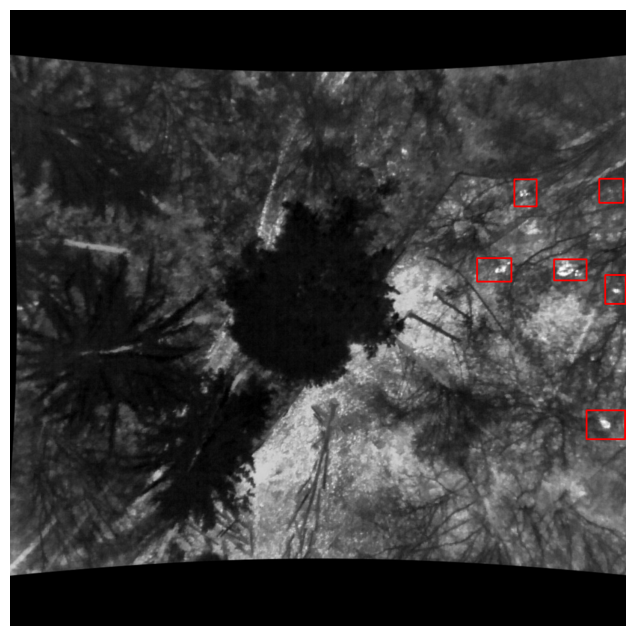

In [14]:
with open(label_file) as f:
    lines = f.readlines()

for line in lines:
    cls, cx, cy, bw, bh = map(float, line.split())

    x1 = int((cx - bw/2) * w)
    y1 = int((cy - bh/2) * h)
    x2 = int((cx + bw/2) * w)
    y2 = int((cy + bh/2) * h)

    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()

Final dataset:

dataset_yolo_detection/

Classes:
- 0: Animal

Samples:

- Train: 14588
- Validation: 1450
- Test: 2101